In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
svm1=pd.read_csv("/purple_cap.csv")

In [7]:
print(svm1)

    Position              Bowler  Team  Matches  Innings  Balls  Overs  \
0          1     Prasidh Krishna    GT       15       15    354   59.0   
1          2          Noor Ahmad   CSK       14       14    300   50.0   
2          3      Josh Hazlewood   RCB       12       12    264   44.0   
3          4         Trent Boult    MI       16       16    346   57.4   
4          5      Arshdeep Singh  PBKS       17       16    350   58.2   
5          6         Sai Kishore    GT       15       15    255   42.3   
6          7      Jasprit Bumrah    MI       12       12    284   47.2   
7          8  Varun Chakravarthy   KKR       13       13    300   50.0   
8          9       Krunal Pandya   RCB       15       15    276   46.0   
9         10   Bhuvneshwar Kumar   RCB       14       14    312   52.0   
10        11       Vaibhav Arora   KKR       12       12    255   42.3   
11        12         Pat Cummins   SRH       14       14    298   49.4   
12        13        Marco Jansen  PBKS

In [8]:
svm1.shape

(15, 14)

In [9]:
svm1.describe()

,Position,Matches,Innings,Balls,Overs,Maidens,Runs,Wickets,Economy_rate,Four_wicket_haul,Five_wicket_hall
count,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.0
mean,8.000000,14.133333,14.00000,299.266667,49.793333,0.133333,436.133333,18.866667,8.752000,0.666667,0.0
std,4.472136,1.457330,1.36277,34.644040,5.778960,0.351866,61.144871,3.113718,0.844057,0.723747,0.0
min,1.000000,12.000000,12.00000,255.000000,42.300000,0.000000,316.000000,16.000000,6.670000,0.000000,0.0
25%,4.500000,13.500000,13.00000,273.000000,45.500000,0.000000,389.500000,16.500000,8.250000,0.000000,0.0
50%,8.000000,14.000000,14.00000,298.000000,49.400000,0.000000,430.000000,17.000000,8.960000,1.000000,0.0
75%,11.500000,15.000000,15.00000,327.000000,54.500000,0.000000,485.500000,21.500000,9.240000,1.000000,0.0
max,15.000000,17.000000,16.00000,354.000000,59.000000,1.000000,527.000000,25.000000,10.110000,2.000000,0.0


In [10]:
svm1.isnull().sum()

,0
Position,0
Bowler,0
Team,0
Matches,0
Innings,0
Balls,0
Overs,0
Maidens,0
Runs,0
Wickets,0


### 1. Preparing Data for SVM
First, let's define our features (X) and target variable (y). For demonstration, we'll classify bowlers into 'high wickets' (above median) and 'low wickets' (at or below median).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Define features (X) and target (y)
# Let's select numerical features that might influence wicket-taking
features = ['Balls', 'Overs', 'Runs', 'Economy_rate', 'Maidens']
X = svm1[features]

# Create a binary target variable: 'high_wickets' (1) if Wickets > median, else 'low_wickets' (0)
median_wickets = svm1['Wickets'].median()
y = (svm1['Wickets'] > median_wickets).astype(int)

print(f"Median Wickets: {median_wickets}")
print("Target variable distribution:")
print(y.value_counts())

Median Wickets: 17.0
Target variable distribution:
Wickets
0    8
1    7
Name: count, dtype: int64


### 2. Splitting Data into Training and Testing Sets
We'll split the dataset into 80% for training and 20% for testing to evaluate the model's performance on unseen data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (12, 5)
X_test shape: (3, 5)
y_train shape: (12,)
y_test shape: (3,)


### 3. Scaling Features
SVMs are sensitive to the scale of the features. It's crucial to scale the data before training the model to ensure all features contribute equally.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


### 4. Training the Support Vector Machine (SVC) Model
Now, let's initialize and train our Support Vector Classifier with a linear kernel.

In [14]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


### 5. Evaluating the Model
Finally, let's evaluate the trained SVM model using the test set to see how well it performs.

In [15]:
y_pred = svm_model.predict(X_test_scaled)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.3333333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



### 6. Visualizing Model Performance on Test Set
Let's visualize the actual vs. predicted labels for the test set using two of the features.

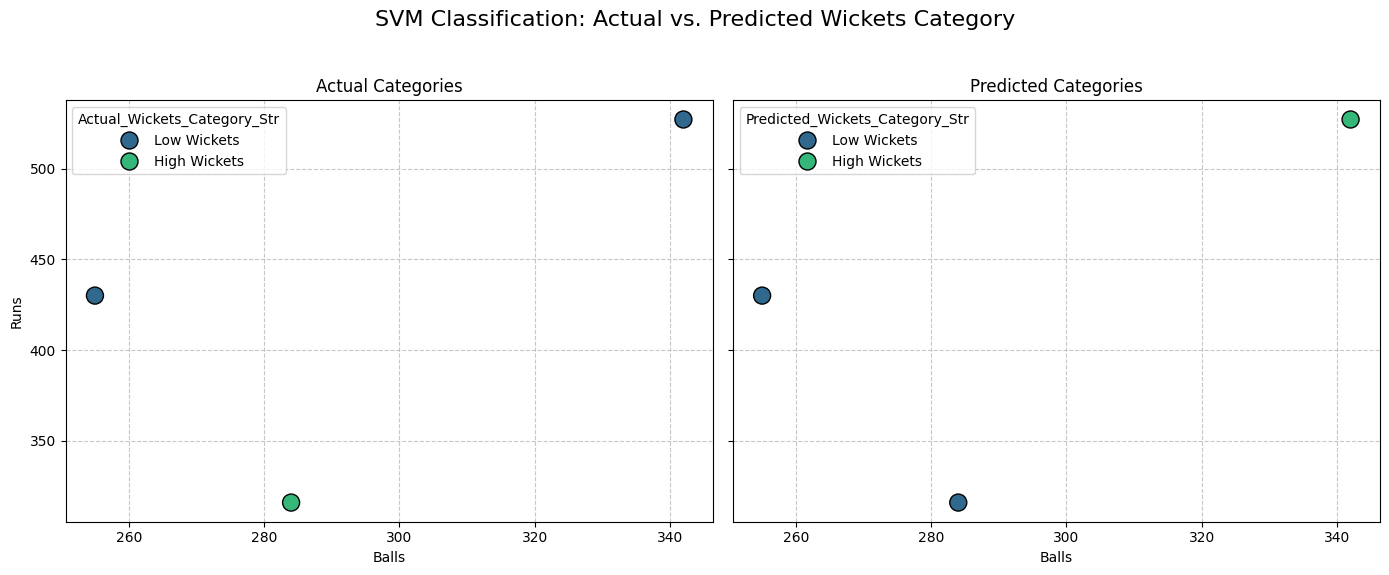

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for easier plotting, including original features, actual and predicted labels
test_results = X_test.copy()
test_results['Actual_Wickets_Category'] = y_test
test_results['Predicted_Wickets_Category'] = y_pred

# Map integer labels to descriptive strings for better plot readability
category_map = {0: 'Low Wickets', 1: 'High Wickets'}
test_results['Actual_Wickets_Category_Str'] = test_results['Actual_Wickets_Category'].map(category_map)
test_results['Predicted_Wickets_Category_Str'] = test_results['Predicted_Wickets_Category'].map(category_map)

# Create subplots to compare actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
fig.suptitle('SVM Classification: Actual vs. Predicted Wickets Category', fontsize=16)

# Plot Actual Categories
sns.scatterplot(
    x='Balls',
    y='Runs',
    hue='Actual_Wickets_Category_Str',
    data=test_results,
    palette='viridis',
    s=150,
    ax=axes[0],
    edgecolor='k',
    linewidth=1
)
axes[0].set_title('Actual Categories')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot Predicted Categories
sns.scatterplot(
    x='Balls',
    y='Runs',
    hue='Predicted_Wickets_Category_Str',
    data=test_results,
    palette='viridis',
    s=150,
    ax=axes[1],
    edgecolor='k',
    linewidth=1
)
axes[1].set_title('Predicted Categories')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 7. Visualizing Support Vectors and Decision Boundary
Let's visualize the support vectors along with the decision boundary for the SVM model trained on 'Balls' and 'Runs'.

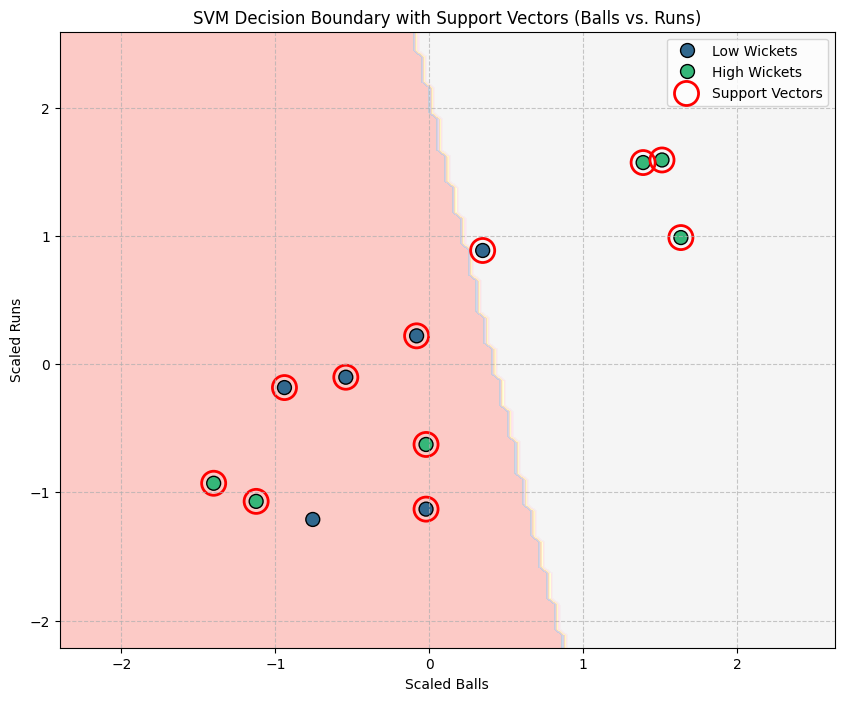

In [17]:
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select two features for 2D visualization
X_2d = X[['Balls', 'Runs']]
y_2d = y

# Define category_map if not already defined (it should be from previous cells)
if 'category_map' not in locals():
    category_map = {0: 'Low Wickets', 1: 'High Wickets'}

# Split and scale the 2D data
X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d)

scaler_2d = StandardScaler()
X_2d_train_scaled = scaler_2d.fit_transform(X_2d_train)
X_2d_test_scaled = scaler_2d.transform(X_2d_test)

# Train a new SVM model on the 2D scaled data
svm_model_2d = SVC(kernel='linear', random_state=42)
svm_model_2d.fit(X_2d_train_scaled, y_2d_train)

# Create a figure and axes
fig_sv, ax_sv = plt.subplots(figsize=(10, 8))

# Plot the decision boundary
DecisionBoundaryDisplay.from_estimator(
    svm_model_2d,
    X_2d_train_scaled,
    response_method="predict",
    plot_method="contourf",
    alpha=0.7,
    cmap="Pastel1",
    ax=ax_sv,
    xlabel='Scaled Balls',
    ylabel='Scaled Runs'
)

# Plot the training data points
sns.scatterplot(
    x=X_2d_train_scaled[:, 0],
    y=X_2d_train_scaled[:, 1],
    hue=y_2d_train.map(category_map),
    palette='viridis',
    s=100,
    ax=ax_sv,
    edgecolor='k',
    linewidth=1
)

# Plot the support vectors (from the training data)
ax_sv.scatter(
    svm_model_2d.support_vectors_[:, 0],
    svm_model_2d.support_vectors_[:, 1],
    s=300, # Larger size to highlight
    facecolors='none', # Transparent face
    edgecolors='red', # Red border for emphasis
    linewidth=2,
    label='Support Vectors'
)

ax_sv.set_title('SVM Decision Boundary with Support Vectors (Balls vs. Runs)')
ax_sv.grid(True, linestyle='--', alpha=0.7)
ax_sv.legend()
plt.show()

### 8. Hyperparameter Tuning with GridSearchCV

To find the best hyperparameters for our SVM model, we'll use `GridSearchCV`. This method systematically works through multiple combinations of parameter values, cross-validating each combination to determine which set of parameters performs best.

In [18]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

# Initialize GridSearchCV
# We'll use the svm_model (trained on all features) for tuning
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=2, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)


Fitting 2 folds for each of 16 candidates, totalling 32 fits
Best parameters found:  {'C': 0.1, 'kernel': 'sigmoid'}
Best cross-validation accuracy:  0.75


### 9. Evaluating the Tuned SVM Model

Now, let's evaluate the SVM model with the best hyperparameters found by `GridSearchCV` on the test set.

In [19]:
from sklearn.metrics import classification_report, accuracy_score

# Get the best model from the grid search
best_svm_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned = best_svm_model.predict(X_test_scaled)

print("Accuracy Score with Tuned Model:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report with Tuned Model:")
print(classification_report(y_test, y_pred_tuned))


Accuracy Score with Tuned Model: 0.3333333333333333

Classification Report with Tuned Model:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



### 10. Comparing with a Random Forest Classifier

Let's train and evaluate a Random Forest Classifier on the same dataset to compare its performance with the SVM model. Random Forest is an ensemble learning method that can often provide good accuracy and handle various types of data well.

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy Score: 0.3333333333333333

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [26]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(best_svm_model, f)

In [27]:
import pickle

# Load the saved model
with open("model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Model loaded successfully!")

Model loaded successfully!


In [28]:
# You can now use 'loaded_model' for predictions or further evaluation
# For example, let's predict on the test set with the loaded model
y_pred_loaded = loaded_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy Score with Loaded Model:", accuracy_score(y_test, y_pred_loaded))
print("\nClassification Report with Loaded Model:")
print(classification_report(y_test, y_pred_loaded))

Accuracy Score with Loaded Model: 0.3333333333333333

Classification Report with Loaded Model:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [29]:
from google.colab import files

files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>